In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print(cm)

[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [3]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, y_pred)
print("정확도:", acc)

정확도: 0.9121265377855887


- 정확도: 전체 예측 건수 중 모델이 올바르게 예측한(맞춘) 건수의 비율

- 알 수 있는 점: 모델이 전체 환자(양성/악성 포함)에 대해 약 90% 내외의 높은 비율로 올바른 진단을 내렸음을 알 수 있다.

**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
from sklearn.metrics import precision_score

prec = precision_score(y, y_pred)
print("정밀도:", prec)

정밀도: 0.900990099009901


- 정밀도: 모델이 '악성(1)'이라고 예측한 것 중 실제로 '악성(1)'인 환자의 비율
- 알 수 있는 점: 모델이 악성으로 진단한 환자들 중에서 실제 악성 환자가 얼마나 포함되어 있는지 검증할 수 있으며, 오진(양성을 악성으로 착각)으로 인한 과도한 불안이나 불필요한 재검사를 줄이는 성능을 알 수 있다.

**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [5]:
from sklearn.metrics import recall_score

rec = recall_score(y, y_pred)
print("재현율:", rec)

재현율: 0.8584905660377359


- 재현율: 실제 '악성(1)'인 환자 전체 중 모델이 '악성(1)'이라고 올바르게 맞춘 비율 (= 민감도)
- 암 진단과 같은 의료 데이터에서는 실제 악성 환자를 놓치는 것(FN)이 치명적이므로 재현율이 매우 중요합니다. 모델이 실제 암 환자를 얼마나 놓치지 않고 잘 찾아냈는지 알 수 있다.

**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [7]:
from sklearn.metrics import f1_score

f1=f1_score(y, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8792270531400966


- F1 score: 정밀도와 재현율의 조화평균으로, 두 지표 중 어느 한쪽으로 치우치지 않고 균형을 이루고 있는지를 나타내는 지표
- 정밀도와 재현율 사이의 트레이드오프 관계를 고려하여 모델의 전반적인 분류 성능이 불균형 없이 우수한지 한눈에 파악할 수 있다.

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [9]:
from sklearn.preprocessing import Binarizer

pred_proba_1=model_lor.predict_proba(X)[:, 1].reshape(-1, 1)

binarizer=Binarizer(threshold=0.9)
y_pred2=binarizer.transform(pred_proba_1)

In [11]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기 // 임계값 변경 후의 성능 지표
print("혼동행렬:\n", confusion_matrix(y, y_pred2))
print("정확도:", accuracy_score(y, y_pred2))
print("정밀도:", precision_score(y, y_pred2))
print("재현율:", recall_score(y, y_pred2))
print("F1 Score:", f1_score(y, y_pred2))

혼동행렬:
 [[356   1]
 [ 73 139]]
정확도: 0.8699472759226714
정밀도: 0.9928571428571429
재현율: 0.6556603773584906
F1 Score: 0.7897727272727273


**ROC 곡선 시각화**

In [12]:
from sklearn.metrics import roc_curve


In [13]:
import matplotlib.pyplot as plt


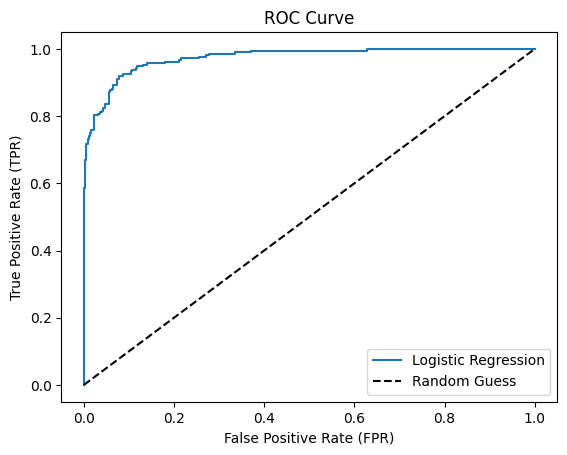

In [14]:
# FPR, TPR, 임계값 구하기
fpr, tpr, thresholds = roc_curve(y, pred_proba_1)

# ROC 곡선 그리기
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # 기준선
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [15]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y, pred_proba_1)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.974076423022039


알 수 있는 점:

- ROC AUC는 ROC 곡선 아래의 면적을 나타내며, 1에 가까울수록 모델의 분류 성능(양성과 악성을 구분하는 능력)이 우수함을 의미한다.
- 계산된 ROC AUC 값이 약 0.95 이상으로 매우 높게 나온다면, 이 모델이 임계값 변동에 관계없이 악성과 양성을 구별하는 판별력이 전반적으로 매우 탁월하다는 것을 알 수 있다.
  - => 위의 경우 값이 약 0.97이 나와 판별력이 탁원함을 알 수 있음.